# Histogramas

Los histogrmas nos ayudan a ver cómo se reparten los datos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()

def literal_eval(cadena):
  if cadena and type(cadena) == str:
    return ast.literal_eval(cadena)
  return cadena

df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(literal_eval)

df.sort_values(by="job_posted_date", inplace = True)

In [2]:
df = df[df["job_title_short"]=="Data Analyst"]
df = df[df["job_country"] == "United States"]

df["month"] = df["job_posted_date"].dt.strftime(format("%B"))
df_exploded = df.explode("job_skills")
df_exploded = df_exploded.sort_values(by="job_posted_date")
df_exploded.reset_index(inplace=True)
df_exploded.set_index("month", inplace=True)

In [3]:
df.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,month
108804,Data Analyst,Data Analyst,"New York, NY",via CareerBuilder,Full-time,False,"New York, United States",2023-01-01 00:00:04,False,False,United States,None,NaN,NaN,Metasys Technologies,"[sql, snowflake, visio, jira, confluence]","{'analyst_tools': ['visio'], 'async': ['jira',...",January
96906,Data Analyst,Data Analyst,"Bloomfield, CT",via CareerBuilder,Full-time,False,"New York, United States",2023-01-01 00:00:07,True,False,United States,None,NaN,NaN,Diverse Lynx,"[sql, sas, sas]","{'analyst_tools': ['sas'], 'programming': ['sq...",January
98438,Data Analyst,Data Analyst,"Washington, DC",via CareerBuilder,Full-time,False,"New York, United States",2023-01-01 00:00:22,False,True,United States,None,NaN,NaN,Guidehouse,"[sql, python, r, azure, snowflake, databricks,...","{'analyst_tools': ['tableau', 'excel'], 'cloud...",January
110290,Data Analyst,Data Analyst,"Fairfax, VA",via CareerBuilder,Full-time,False,"New York, United States",2023-01-01 00:00:24,False,False,United States,None,NaN,NaN,Protask,"[sql, jira]","{'async': ['jira'], 'programming': ['sql']}",January
104526,Data Analyst,Jr. Data Analyst,"Torrance, CA",via Recruit.net,Full-time,False,"California, United States",2023-01-01 00:00:38,False,False,United States,None,NaN,NaN,Aquent,[excel],{'analyst_tools': ['excel']},January


<Axes: ylabel='Frequency'>

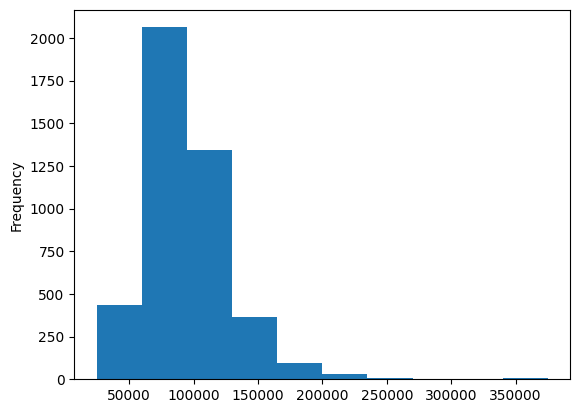

In [4]:
df["salary_year_avg"].plot(kind="hist")

<Axes: ylabel='Frequency'>

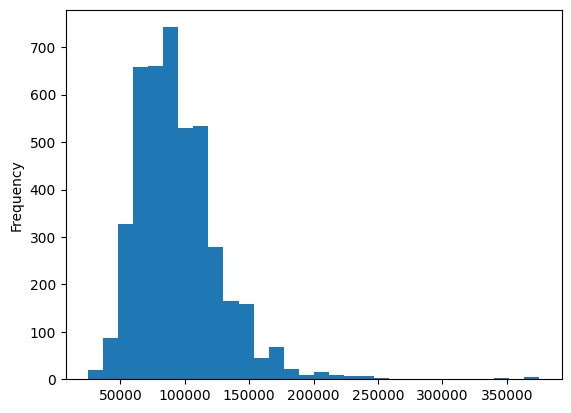

In [5]:
df["salary_year_avg"].plot(kind="hist", bins=30)

<Axes: ylabel='Frequency'>

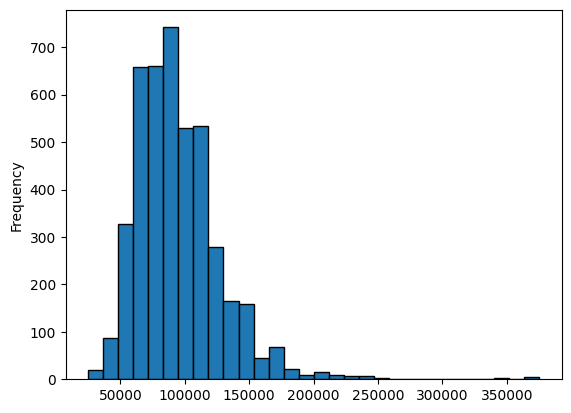

In [6]:
df["salary_year_avg"].plot(kind="hist", bins= 30, edgecolor= "k")

# Esta gráfica nos muestra que está skewed to de right.

Podemos evitar que se grafique empleando un límite de x

<Axes: ylabel='Frequency'>

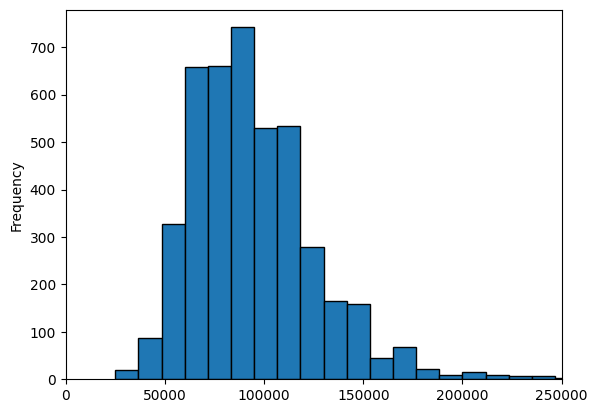

In [7]:
df["salary_year_avg"].plot(kind="hist", bins= 30, edgecolor= "k", xlim=(0, 250000))

Text(0, 0.5, 'Frequency')

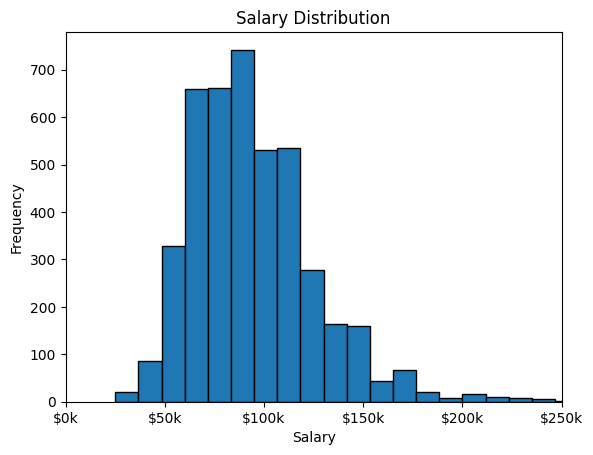

In [8]:
df["salary_year_avg"].plot(kind="hist", bins= 30, edgecolor= "k", xlim=(0, 250000))

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${format(int(x/1000))}k'))

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")

# Boxplots

son otra herramienta muy útil para entender cómo se distribuyen nuestros datos. También llamado diagrama de caja y bigotes.

<Axes: >

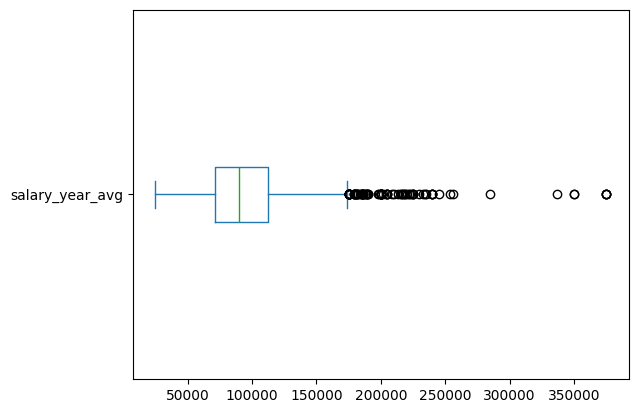

In [9]:
df["salary_year_avg"].plot(kind="box", vert=False)

## NaN values in box plots
Pandas maneja los valores NaN de forma automática, si usamos pyplot debemos manejarl esos valores

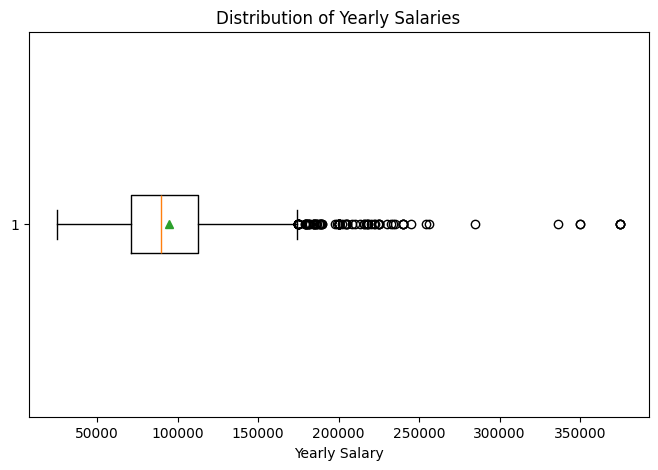

In [10]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    df["salary_year_avg"].dropna(),
    vert=False,
    showmeans=True
)

plt.xlabel("Yearly Salary")
plt.title("Distribution of Yearly Salaries")
plt.show()

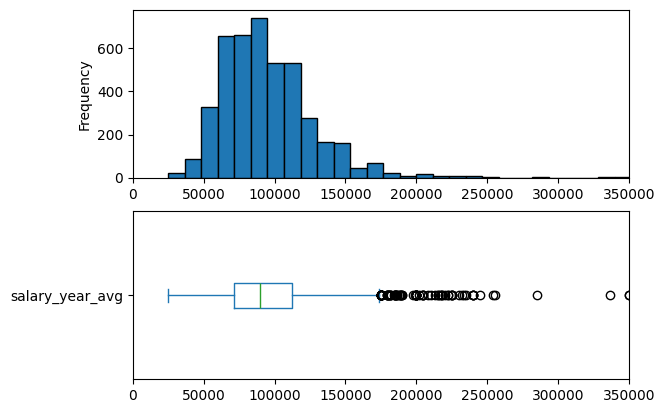

In [11]:
fig, ax = plt.subplots(2, 1)

df["salary_year_avg"].plot(
    kind="hist",
    bins=30,
    edgecolor="k",
    xlim=(0, 350000),
    ax=ax[0]
)

df["salary_year_avg"].plot(
    kind="box",
    vert=False,
    xlim=(0, 350000),
    ax=ax[1]
)

plt.show()

# Multiplot

In [12]:
df = ds["train"].to_pandas()

def literal_eval(cadena):
  if cadena and type(cadena) == str:
    return ast.literal_eval(cadena)
  return cadena

df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(literal_eval)

df.sort_values(by="job_posted_date", inplace = True)

df = df[df["job_country"] == "United States"]

df["month"] = df["job_posted_date"].dt.strftime(format("%B"))
df_exploded = df.explode("job_skills")
df_exploded = df_exploded.sort_values(by="job_posted_date")
df_exploded.reset_index(inplace=True)
df_exploded.set_index("month", inplace=True)

In [13]:
job_titles = df["job_title_short"].value_counts().head(3).index.tolist()
job_titles

['Data Analyst', 'Data Scientist', 'Data Engineer']

In [14]:
df = df[df["job_title_short"].isin(job_titles)]
df.dropna(subset="salary_year_avg", inplace=True)

/tmp/ipykernel_22947/2269922566.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False)


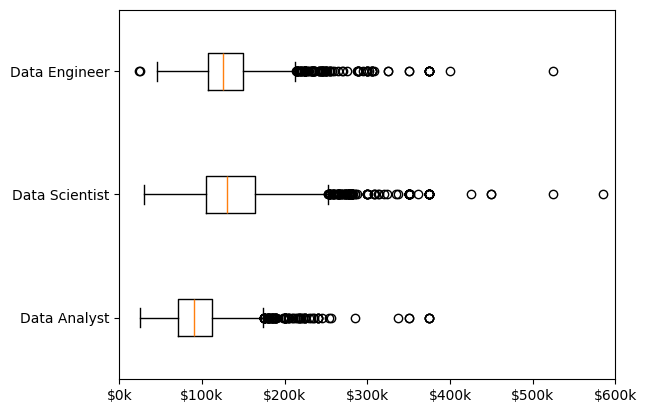

In [15]:
job_list = [df[df["job_title_short"]== job_title]["salary_year_avg"] for job_title in job_titles]

plt.boxplot(job_list, labels=job_titles, vert=False)
plt.xlim(0, 600000)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${format(int(x/1000))}k'))


plt.show()